In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df  = pd.read_csv(r"D:\Car prediction\Car details v3.csv")
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [4]:
df.shape

(8128, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB


In [6]:
df.describe()

,year,selling_price,km_driven,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,5.416719
std,4.044249,8.062534e+05,5.655055e+04,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,14.000000


In [7]:
df["engine"].value_counts()

engine
1248 CC    1017
1197 CC     832
998 CC      453
796 CC      444
2179 CC     389
           ... 
2650 CC       1
2446 CC       1
3498 CC       1
2776 CC       1
1950 CC       1
Name: count, Length: 121, dtype: int64

In [8]:
df["selling_price"].max()

np.int64(10000000)

In [9]:
df["selling_price"].min()

np.int64(29999)

In [10]:
df.isna().sum()


name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64

In [11]:
df.shape

(8128, 13)

In [12]:
df['mileage'] = df['mileage'].str.extract(r'(\d+\.?\d*)')
df['mileage'] = pd.to_numeric(df['mileage'], errors='coerce')

In [13]:
df['engine'] = df['engine'].str.extract(r'(\d+\.?\d*)')
df['engine'] = pd.to_numeric(df['engine'], errors='coerce')

In [14]:
df['max_power'] = df['max_power'].str.extract(r'(\d+\.?\d*)')
df['max_power'] = pd.to_numeric(df['max_power'], errors='coerce')

In [15]:
df['mileage'] = df['mileage'].fillna(df['mileage'].median())
df['engine'] = df['engine'].fillna(df['engine'].median())
df['max_power'] = df['max_power'].fillna(df['max_power'].median())
df['seats'] = df['seats'].fillna(df['seats'].mode()[0])

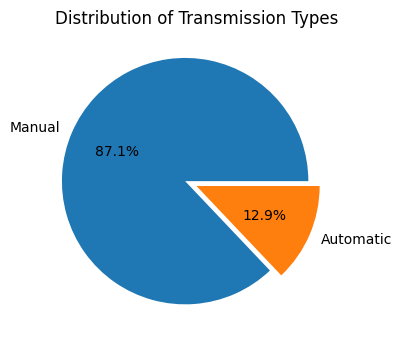

In [16]:
# Visualization

plt.figure(figsize=(4,4))
plt.pie(df["transmission"].value_counts(), labels=df["transmission"].value_counts().index, 
        autopct="%1.1f%%" , explode=[0.1,0])
plt.title("Distribution of Transmission Types")
plt.show()

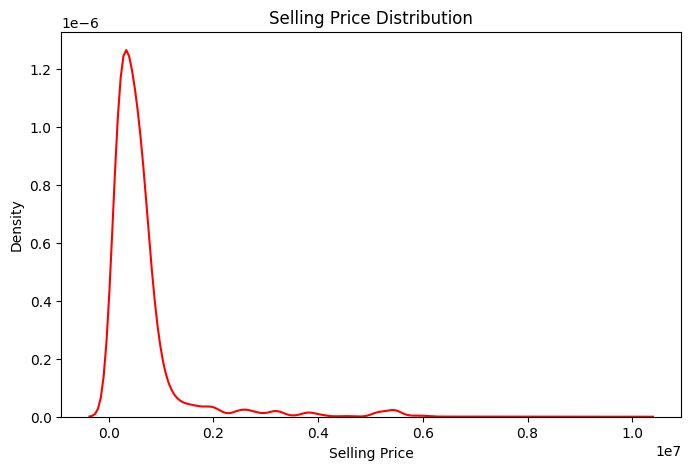

In [17]:
plt.figure(figsize=(8,5))
sns.kdeplot(
    data=df,
    x='selling_price',
    color='red'
)

plt.title("Selling Price Distribution")
plt.xlabel("Selling Price")
plt.ylabel("Density")
plt.show()

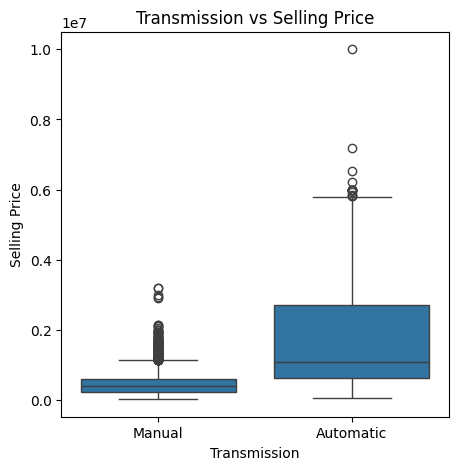

In [18]:
plt.figure(figsize=(5,5))

sns.boxplot(
    x="transmission",
    y="selling_price",
    data=df
)

plt.title("Transmission vs Selling Price")
plt.xlabel("Transmission")
plt.ylabel("Selling Price")
plt.show()

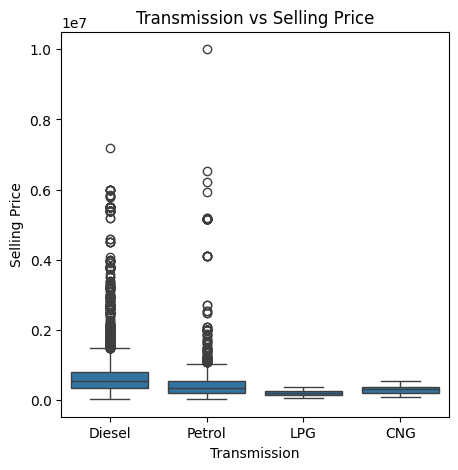

In [19]:
plt.figure(figsize=(5,5))

sns.boxplot(
    x="fuel",
    y="selling_price",
    data=df
)

plt.title("Transmission vs Selling Price")
plt.xlabel("Transmission")
plt.ylabel("Selling Price")
plt.show()

In [20]:
# corelation

df.columns

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'mileage', 'engine', 'max_power', 'torque',
       'seats'],
      dtype='object')

In [21]:
corr = ['selling_price', 'mileage', 'engine', 'km_driven', 'year', 'max_power', 'seats']

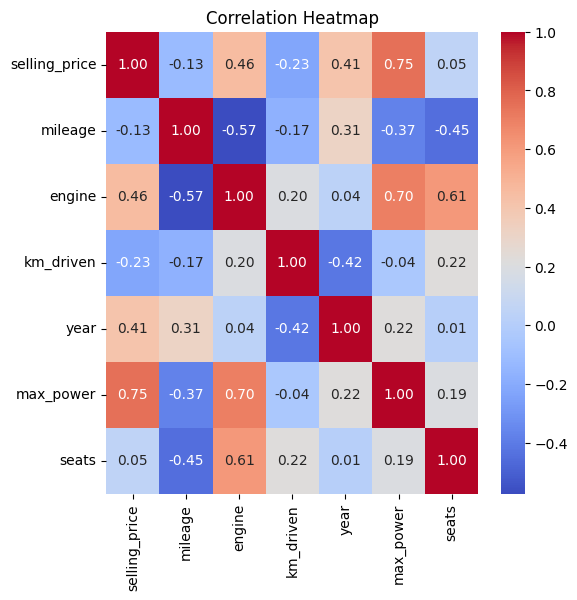

In [22]:
plt.figure(figsize=(6,6))
sns.heatmap(
    df[corr].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title("Correlation Heatmap")
plt.show()

In [23]:
df.drop('torque', axis=1, inplace=True)

In [24]:
df

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai i20 Magna,2013,320000,110000,Petrol,Individual,Manual,First Owner,18.50,1197.0,82.85,5.0
8124,Hyundai Verna CRDi SX,2007,135000,119000,Diesel,Individual,Manual,Fourth & Above Owner,16.80,1493.0,110.00,5.0
8125,Maruti Swift Dzire ZDi,2009,382000,120000,Diesel,Individual,Manual,First Owner,19.30,1248.0,73.90,5.0
8126,Tata Indigo CR4,2013,290000,25000,Diesel,Individual,Manual,First Owner,23.57,1396.0,70.00,5.0


In [25]:
df['brand'] = df['name'].str.split().str[0]
df.drop('name', axis=1, inplace=True)

In [26]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cat_cols = [
    'brand',
    'fuel',
    'seller_type',
    'transmission',
    'owner'
]

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [27]:
df.head(3)

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,brand
0,2014,450000,145500,1,1,1,0,23.40,1248.0,74.00,5.0,20
1,2014,370000,120000,1,1,1,2,21.14,1498.0,103.52,5.0,27
2,2006,158000,140000,3,1,1,4,17.70,1497.0,78.00,5.0,10


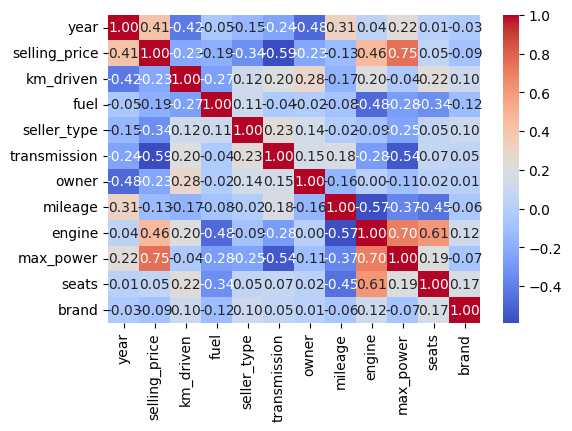

In [28]:
plt.figure(figsize=(6,4))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.show()

In [29]:
X = df.drop('selling_price', axis=1)
y = df['selling_price']

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [31]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor
)

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

In [32]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Extra Trees": ExtraTreesRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42),
    "LightGBM": LGBMRegressor(random_state=42),
    "CatBoost": CatBoostRegressor(verbose=0, random_state=42)
}

In [33]:
from sklearn.metrics import r2_score

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    score = r2_score(y_test, pred)

    results.append([name, score])

results

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002001 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 862
[LightGBM] [Info] Number of data points in the train set: 6502, number of used features: 11
[LightGBM] [Info] Start training from score 638656.852815


[['Linear Regression', 0.6877397386486502],
 ['Ridge', 0.6877524222739777],
 ['Lasso', 0.6877401331226172],
 ['Decision Tree', 0.9216361813276411],
 ['Random Forest', 0.969798391788369],
 ['Extra Trees', 0.9734632536432338],
 ['Gradient Boosting', 0.9602737668464935],
 ['XGBoost', 0.9589158892631531],
 ['LightGBM', 0.9692534433095601],
 ['CatBoost', 0.9711892349311495]]

In [34]:
results = pd.DataFrame(
    results,
    columns=["Model", "R2 Score"]
)

results.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,R2 Score
5,Extra Trees,0.973463
9,CatBoost,0.971189
4,Random Forest,0.969798
8,LightGBM,0.969253
6,Gradient Boosting,0.960274
7,XGBoost,0.958916
3,Decision Tree,0.921636
1,Ridge,0.687752
2,Lasso,0.687740
0,Linear Regression,0.687740


In [35]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    mse = mean_squared_error(y_test, pred)
    rmse = mse**0.5
    r2 = r2_score(y_test, pred)

    results.append([name, mae, rmse, r2])

results = pd.DataFrame(
    results,
    columns=["Model","MAE","RMSE","R2"]
)

results.sort_values("R2", ascending=False)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000414 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 862
[LightGBM] [Info] Number of data points in the train set: 6502, number of used features: 11
[LightGBM] [Info] Start training from score 638656.852815


,Model,MAE,RMSE,R2
5,Extra Trees,65696.211899,131887.923389,0.973463
9,CatBoost,68403.749095,137422.735451,0.971189
4,Random Forest,68555.893322,140700.690325,0.969798
8,LightGBM,73144.146062,141964.395207,0.969253
6,Gradient Boosting,87294.203578,161368.918036,0.960274
7,XGBoost,70442.234375,164103.563008,0.958916
3,Decision Tree,84570.738816,226641.266830,0.921636
1,Ridge,270912.720170,452408.475554,0.687752
2,Lasso,270916.669969,452417.378204,0.687740
0,Linear Regression,270917.177119,452417.663970,0.687740


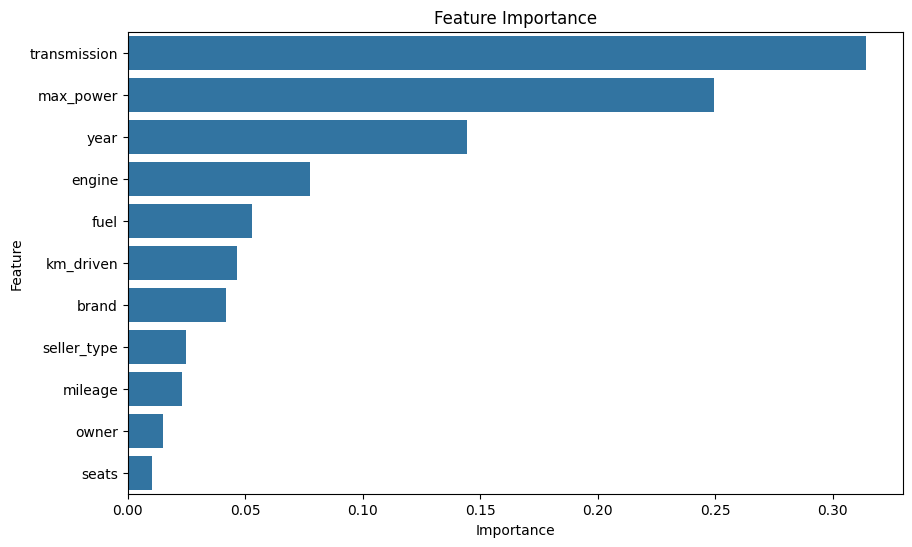

In [36]:
best_model = ExtraTreesRegressor(random_state=42)
best_model.fit(X_train, y_train)

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))
sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)
plt.title("Feature Importance")
plt.show()

In [37]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import ExtraTreesRegressor

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

grid = GridSearchCV(
    estimator=ExtraTreesRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",ExtraTreesReg...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold 

In [38]:
print(grid.best_params_)

{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [39]:
best_model = grid.best_estimator_

In [40]:
y_pred = best_model.predict(X_test)

In [41]:
import joblib

joblib.dump(best_model, "car_price_model.pkl")

['car_price_model.pkl']

In [44]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

cat_cols = [
    'brand',
    'fuel',
    'seller_type',
    'transmission',
    'owner'
]

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le
joblib.dump(encoders, "label_encoders.pkl")

['label_encoders.pkl']